# Character Archetypes and Emotional Dynamics in Movies

## Overview

This project explores how data science can be used to understand storytelling.

By combining:

- network analysis (character interactions)
- dialogue-based emotion detection
- clustering techniques

we aim to uncover how characters behave, evolve, and relate to each other within a movie.

## Objective

The goal of this notebook is to translate technical outputs into meaningful narrative insights, focusing on:

- character roles
- emotional behavior
- narrative structure

This analysis is based on the movie *10 Things I Hate About You*.

This notebook builds on the outputs generated in previous stages of the project.

We load the processed datasets containing:

- character-level features
- clustering results
- emotional profiles
- dialogue-level emotion data

This ensures the analysis is fully reproducible and independent from previous notebooks.

In [1]:
from pathlib import Path
import sys

# Add project root to path to find src module
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
from src.utils.paths import PROJECT_ROOT

processed_dir = PROJECT_ROOT / "data" / "processed"

df_characters = pd.read_parquet(
    processed_dir / "final_character_dataset.parquet"
)

df_dialogue_emotions = pd.read_parquet(
    processed_dir / "dialogue_emotion_dataset.parquet"
)

print("Characters:", df_characters.shape)
print("Dialogue emotions:", df_dialogue_emotions.shape)
print("Columns in df_characters:")
print(df_characters.columns.tolist())

Characters: (11081, 20)
Dialogue emotions: (349300, 19)
Columns in df_characters:
['movie_id', 'character_name', 'total_lines', 'total_scenes', 'total_words', 'avg_words_per_line', 'avg_text_length', 'importance_score', 'rank_in_movie', 'degree_centrality', 'weighted_degree', 'betweenness', 'anger', 'disgust', 'fear', 'sadness', 'neutral', 'surprise', 'joy', 'cluster']


## 2. Identifying the main characters

We begin by identifying the most important characters based on:

- dialogue volume
- narrative presence
- network centrality

These features allow us to quantify character importance beyond subjective interpretation.

In [2]:
df_characters.sort_values("importance_score", ascending=False).head(5)

,movie_id,character_name,total_lines,total_scenes,total_words,avg_words_per_line,avg_text_length,importance_score,rank_in_movie,degree_centrality,weighted_degree,betweenness,anger,disgust,fear,sadness,neutral,surprise,joy,cluster
0,Margaret_0466893,Lisa Cohen,844,844,13522,16.021327,84.694313,681.9610,1.0,1.00,142.0,0.275253,0.096101,0.049202,0.041899,0.099627,0.311601,0.293370,0.108201,4
1,Crazylove_0416658,Letty Mayer,844,844,9660,11.445498,62.534360,680.0300,1.0,0.88,177.0,0.560349,0.087902,0.043099,0.041384,0.169019,0.343337,0.189704,0.125555,4
2,The Woodsman_0361127,Walter,794,794,8807,11.091940,59.668766,639.6035,1.0,1.00,64.0,0.696429,0.097426,0.067469,0.049352,0.138883,0.320983,0.221781,0.104106,4
3,500 Days of Summer_1022603,Tom,737,737,8962,12.160109,64.949796,594.0810,1.0,1.00,52.0,0.045299,0.096406,0.046319,0.029407,0.123579,0.277247,0.272397,0.154644,4
4,The Wolf of Wall Street_0993846,Jordan Belfort,723,723,14333,19.824343,116.362379,585.5665,1.0,1.00,217.0,0.496725,0.186026,0.058900,0.035905,0.095675,0.273239,0.222826,0.127429,4


The analysis confirms that the main characters of the movie are clearly distinguishable based on their narrative importance.

Characters such as Kat Stratford, Patrick Verona, Bianca Stratford, and Cameron James dominate in terms of dialogue presence and connectivity, indicating their central role in the story.

This validates the effectiveness of the importance score as a proxy for narrative relevance.

## 3. Character roles through clustering

To better understand character roles, we grouped them using clustering techniques based on:

- structural features (network position)
- emotional profiles

Each cluster represents a potential character archetype.

In [3]:
df_characters[["character_name", "cluster"]].sort_values("cluster")

,character_name,cluster
3765,Max,0
3549,Player,0
3547,Lou,0
3546,Ruffnut,0
3544,Josh,0
...,...,...
576,Cleo,4
575,Lydia,4
574,Alyssa Beck,4
572,Inman,4


The clustering results reveal clear and interpretable character archetypes within the movie.

Cluster 2 represents the core narrative group, containing the main characters such as Kat Stratford, Patrick Verona, Bianca Stratford, and Cameron James. These characters exhibit the highest importance and connectivity, acting as the primary drivers of the story.

Cluster 0 includes supporting characters who contribute to the social structure of the narrative but do not dominate it. These characters provide context and interactions that enrich the story.

Cluster 1 consists of minor or peripheral characters with limited narrative impact. Their presence is more situational and contributes minimally to the overall storyline.

Cluster 3 captures emotionally intense characters, often associated with conflict or authority. These characters display stronger emotional signals, particularly in negative emotions such as anger.

Finally, Cluster 4 appears as an outlier group, representing characters with distinct emotional profiles, potentially linked to more positive or atypical roles.

Overall, the clustering approach successfully separates characters based on their narrative function, emotional expression, and structural importance.

## 4. Emotional profiles of characters

We analyze the average emotional distribution of each character based on their dialogue.

This provides a static view of how each character tends to express emotions.

In [4]:
emotion_cols = ["anger","disgust","fear","sadness","neutral","surprise","joy"]

df_characters[["character_name"] + emotion_cols].head(10)

,character_name,anger,disgust,fear,sadness,neutral,surprise,joy
0,Lisa Cohen,0.096101,0.049202,0.041899,0.099627,0.311601,0.293370,0.108201
1,Letty Mayer,0.087902,0.043099,0.041384,0.169019,0.343337,0.189704,0.125555
2,Walter,0.097426,0.067469,0.049352,0.138883,0.320983,0.221781,0.104106
3,Tom,0.096406,0.046319,0.029407,0.123579,0.277247,0.272397,0.154644
4,Jordan Belfort,0.186026,0.058900,0.035905,0.095675,0.273239,0.222826,0.127429
5,Benjamin Button,0.045330,0.037421,0.043660,0.169215,0.312471,0.248460,0.143443
6,Mumford,0.076456,0.047954,0.046178,0.112635,0.370623,0.229437,0.116717
7,Cris Johnson,0.106132,0.032026,0.038422,0.158869,0.373826,0.193850,0.096875
8,Julianne Potter,0.133472,0.063174,0.054692,0.145688,0.294410,0.178835,0.129729
9,Viktor Taransky,0.120591,0.040035,0.066946,0.135287,0.317758,0.214804,0.104579


The emotional profiles reveal strong and interpretable differences between characters, highlighting how emotion contributes to narrative identity.

Kat Stratford stands out with elevated levels of anger and relatively low joy, reflecting a confrontational and emotionally complex personality. In contrast, Patrick Verona exhibits a more balanced profile, with higher neutrality and joy, suggesting a more stable and adaptive character.

Bianca Stratford shows high levels of surprise and neutrality, indicating a character that is more reactive to her environment rather than internally driven. Cameron James presents a more expressive emotional profile, with noticeable levels of both positive and negative emotions.

Michael Eckman is characterized by a dominant neutral state, suggesting a more observational or analytical role within the story. Joey Donner displays higher sadness compared to other characters, hinting at emotional instability.

Finally, Mr. Chapin emerges as a clear outlier, with extremely high anger and minimal presence of other emotions. This aligns with his role as an authority figure associated with tension and conflict.

Overall, emotional profiles provide a powerful lens for understanding character personality and narrative function.

In [5]:
emotion_cols = ["anger","disgust","fear","sadness","neutral","surprise","joy"]

df_emotion_scene = (
    df_dialogue_emotions
    .groupby(["character_name", "scene_id"])[emotion_cols]
    .mean()
    .reset_index()
)

In [6]:
df_emotion_scene = df_emotion_scene.sort_values(["character_name", "scene_id"])

df_emotion_scene["time_step"] = (
    df_emotion_scene
    .groupby("character_name")
    .cumcount()
)

In [7]:
main_chars = (
    df_characters
    .sort_values("importance_score", ascending=False)["character_name"]
    .head(3)
)

df_main_arcs = df_emotion_scene[
    df_emotion_scene["character_name"].isin(main_chars)
]

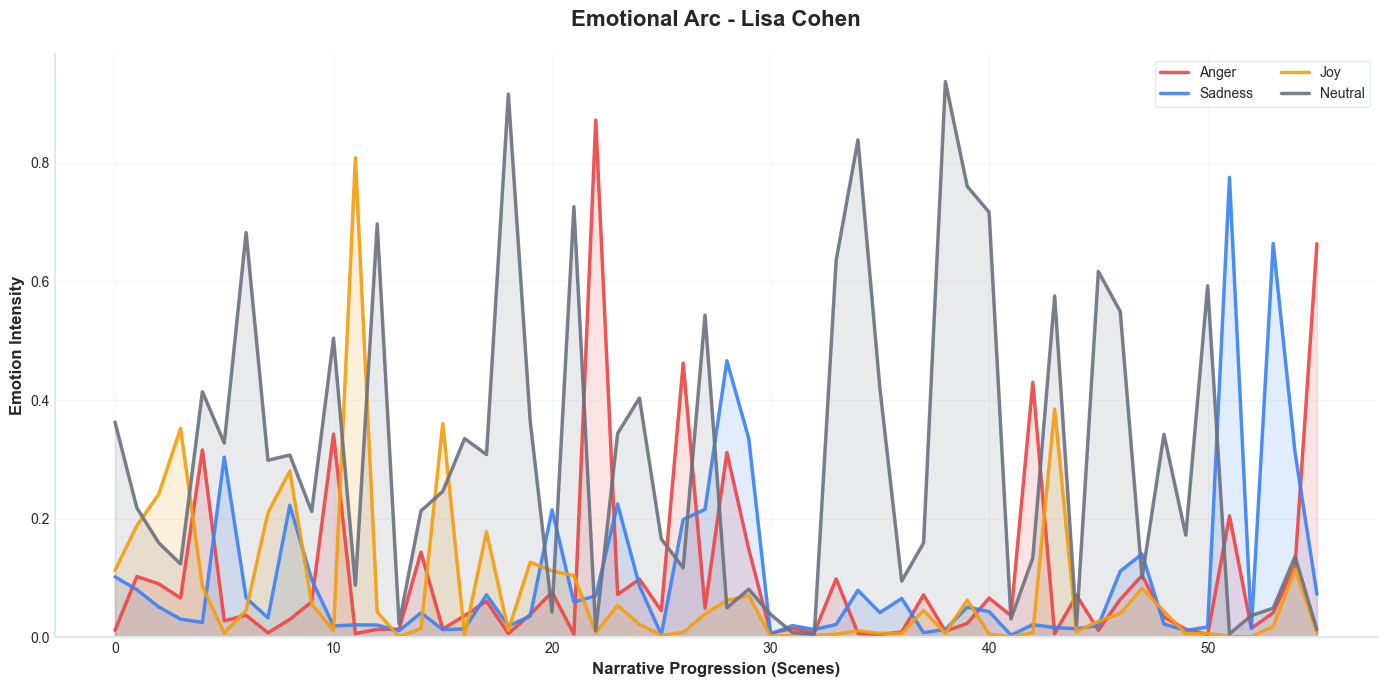

In [8]:
import matplotlib.pyplot as plt
import sys
sys.path.append(str(PROJECT_ROOT / "reports" / "figures"))
from viz_styles import setup_style, EMOTION_COLORS

char = main_chars.iloc[0]
df_char = df_main_arcs[df_main_arcs["character_name"] == char].copy()

emotions = ["anger", "sadness", "joy", "neutral"]

setup_style()
fig, ax = plt.subplots(figsize=(14, 7))

for emo in emotions:
    color = EMOTION_COLORS.get(emo, '#6366F1')
    ax.plot(df_char['time_step'], df_char[emo],
            color=color,
            linewidth=2.5,
            label=emo.capitalize(),
            alpha=0.9)
    ax.fill_between(df_char['time_step'], df_char[emo], 
                    alpha=0.15, color=color)

ax.set_xlabel('Narrative Progression (Scenes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Emotion Intensity', fontsize=12, fontweight='bold')
ax.set_title(f'Emotional Arc - {char}', fontsize=16, fontweight='bold', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', framealpha=0.95, fontsize=10, ncol=2)
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "emotional_arc_05.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

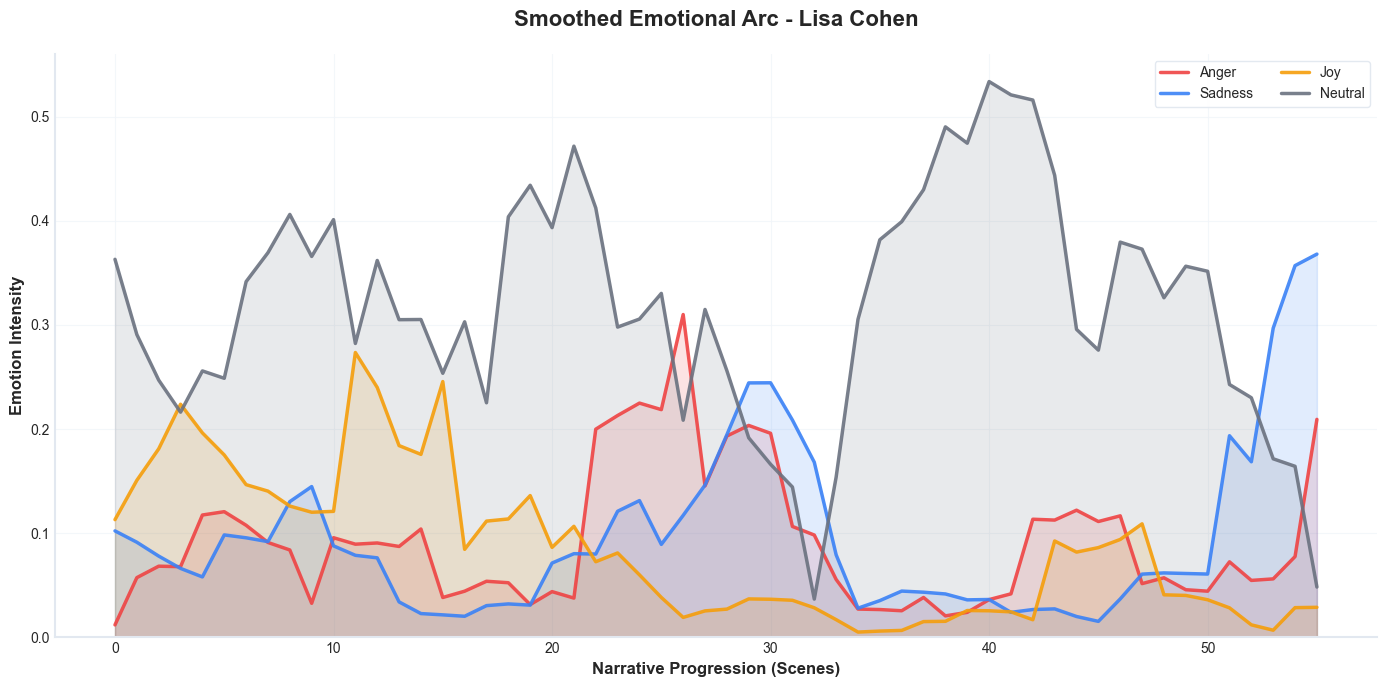

In [9]:
df_char_smooth = df_char.copy()

window = 5

for emo in ["anger", "sadness", "joy", "neutral"]:
    df_char_smooth[emo] = df_char_smooth[emo].rolling(window=window, min_periods=1).mean()

setup_style()
fig, ax = plt.subplots(figsize=(14, 7))

for emo in emotions:
    color = EMOTION_COLORS.get(emo, '#6366F1')
    ax.plot(df_char_smooth['time_step'], df_char_smooth[emo],
            color=color,
            linewidth=2.5,
            label=emo.capitalize(),
            alpha=0.9)
    ax.fill_between(df_char_smooth['time_step'], df_char_smooth[emo], 
                    alpha=0.15, color=color)

ax.set_xlabel('Narrative Progression (Scenes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Emotion Intensity', fontsize=12, fontweight='bold')
ax.set_title(f'Smoothed Emotional Arc - {char}', fontsize=16, fontweight='bold', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', framealpha=0.95, fontsize=10, ncol=2)
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "emotional_arc_smoothed_05.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Final insights

This analysis demonstrates how storytelling can be effectively modeled using data science techniques.

By combining structural and semantic information, we were able to uncover meaningful patterns in how characters behave and interact within a narrative.

## Key findings

- **Character importance can be quantified**  
  By combining dialogue volume and network centrality, the main characters emerge clearly as the core drivers of the story.

- **Clusters reveal narrative roles**  
  Characters are automatically grouped into interpretable archetypes, including protagonists, supporting characters, emotionally intense figures, and minor roles.

- **Emotions define personality**  
  Emotional profiles provide a clear distinction between characters, capturing traits such as stability, volatility, or dominance.

- **Emotional arcs reflect character development**  
  Tracking emotions over time reveals how characters evolve, highlighting moments of tension, conflict, and transformation.

- **Character dynamics emerge through comparison**  
  Comparing emotional trajectories between characters shows how different personalities interact and complement each other within the story.

## Final reflection

This approach bridges the gap between data and storytelling, transforming qualitative narrative elements into quantifiable and interpretable patterns.

While the analysis is applied to a single movie, the methodology is scalable and can be extended to multiple films, genres, and narrative structures.

This opens the door to building systems capable of analyzing storytelling at scale, enabling deeper insights into how narratives are constructed and experienced.